# 1D Steady Heat Equation — PINN First Experiment

**PDE:** $-\frac{d^2 T}{dx^2} = Q(x)$ on $x \in [0, 1]$
**Source:** $Q(x) = \pi^2 \sin(\pi x)$
**Boundary conditions:** $T(0) = T(1) = 0$
**Analytical solution:** $T(x) = \sin(\pi x)$

This notebook is a **thin driver** — all heavy logic (`MLP`, PDE loss, training loop) lives in `src/`.
Purpose: interactive experimentation, hyperparameter tweaking, and inspection of intermediate state.

## Success criteria (baseline established by `python -m src.train`)
- Relative L2 error vs analytical solution ≤ 1e-2
- Total loss drops ~4 orders of magnitude over 5000 epochs

## 1. Path setup — make `src/` importable

Jupyter's working directory is the notebook's folder (`notebooks/`), not the project root.
So `from src.model import MLP` would fail with `ModuleNotFoundError: No module named 'src'`
— same `sys.path` issue we already understand.

**Fix:** prepend the project root (parent of `notebooks/`) to `sys.path`.
This is the standard notebook idiom; every ML project's notebooks start this way.

In [1]:
import sys
from pathlib import Path

# Add project root (parent of notebooks/) to sys.path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("sys.path", sys.path[0])

Project root: /proj/cmc3/cmc_users/sroy5/python_dev/pinn_gan_selfheating
sys.path /proj/cmc3/cmc_users/sroy5/python_dev/pinn_gan_selfheating


## 2. Imports and reproducibility

Standard scientific Python stack + our `src/` modules. Fixing `torch.manual_seed`
makes runs bit-for-bit reproducible: identical loss curves, identical L2 error.
Without a fixed seed, two runs would give slightly different results due to
random weight initialization in the MLP.

In [2]:
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

from src.model import MLP
from src.pde_loss import pde_residual, boundary_loss

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("PyTorch:", torch.__version__)
print("Seed:", SEED)

PyTorch: 2.12.1+cpu
Seed: 42


## 3. Configuration

Hyperparameters live in one visible cell — easy to tweak and rerun.
This is the notebook's superpower: change `LAMBDA_BC = 100` → `LAMBDA_BC = 10`
and rerun cells 6–9 in ~30 s to see the effect. No file editing, no restart.

In [3]:
# Hyperparameters
N_COLLOCATION = 200
N_EPOCHS      = 5000
LR            = 1e-3
LAMBDA_BC     = 100.0
LOG_EVERY     = 500

## 4. Instantiate model, optimizer, collocation points

Three objects, one cell each mentally:

- **Model** — the neural network $T_\theta(x)$, parameterized by ~3.5k weights.
- **Optimizer** — Adam, which will update those weights using loss gradients.
- **Collocation points** — 200 uniformly spaced $x$ values on $[0, 1]$ where we
  evaluate the PDE residual. `requires_grad_(True)` is essential: it tells
  autograd to build a computation graph tracking derivatives w.r.t. $x$,
  which is what enables $T''(x)$ inside `pde_residual`.

In [4]:
model     = MLP(in_dim=1, out_dim=1, hidden_dim=32, n_hidden=4)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

x_colloc = torch.linspace(0.0, 1.0, N_COLLOCATION).view(-1, 1)
x_colloc.requires_grad_(True)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {n_params} trainable parameters")
print(f"Collocation points: {x_colloc.shape}, requires_grad={x_colloc.requires_grad}")

Model: 3265 trainable parameters
Collocation points: torch.Size([200, 1]), requires_grad=True


## 5. Training loop

Same logic as `train.py`, unrolled into the notebook so we can inspect intermediate state.
The three lines that matter each epoch:

1. `optimizer.zero_grad()` — clear stale gradients (PyTorch **accumulates** by default,
   a design choice for RNNs; forgetting this is the #1 PyTorch bug).
2. `loss.backward()` — reverse-mode autodiff fills `.grad` on every model parameter.
3. `optimizer.step()` — Adam updates weights using those gradients.

The double-differentiation dance happens inside `pde_residual`: autograd first computes
$T'$ then $T''$ with `create_graph=True`, keeping the derivative graph alive so that
`loss.backward()` can propagate all the way back to $\theta$. **Mixed partial derivatives
across two variable types (x and θ) — autograd handles it transparently.**

In [5]:
hist_total, hist_pde, hist_bc = [], [], []

for epoch in range(1, N_EPOCHS + 1):
    optimizer.zero_grad()

    r = pde_residual(model, x_colloc)
    loss_pde = torch.mean(r ** 2)
    loss_bc  = boundary_loss(model)
    loss     = loss_pde + LAMBDA_BC * loss_bc

    loss.backward()
    optimizer.step()

    hist_total.append(loss.item())
    hist_pde.append(loss_pde.item())
    hist_bc.append(loss_bc.item())

    if epoch % LOG_EVERY == 0 or epoch == 1:
        print(f"epoch {epoch:5d} | total {loss.item():.3e} "
              f"| pde {loss_pde.item():.3e} | bc {loss_bc.item():.3e}")

print("\nTraining complete.")

epoch     1 | total 5.166e+01 | pde 5.004e+01 | bc 1.621e-02
epoch   500 | total 3.233e-02 | pde 3.232e-02 | bc 9.294e-08
epoch  1000 | total 1.460e-02 | pde 1.460e-02 | bc 2.736e-08
epoch  1500 | total 6.633e-03 | pde 6.630e-03 | bc 2.649e-08
epoch  2000 | total 3.611e-03 | pde 3.216e-03 | bc 3.946e-06
epoch  2500 | total 1.134e-02 | pde 2.039e-03 | bc 9.302e-05
epoch  3000 | total 8.102e-04 | pde 8.023e-04 | bc 7.904e-08
epoch  3500 | total 4.599e-04 | pde 4.599e-04 | bc 1.119e-11
epoch  4000 | total 2.534e-04 | pde 2.534e-04 | bc 1.325e-10
epoch  4500 | total 1.483e-04 | pde 1.470e-04 | bc 1.284e-08
epoch  5000 | total 1.103e-04 | pde 1.103e-04 | bc 3.169e-12

Training complete.


## 6. Evaluate against analytical solution

`model.eval()` switches modules like `Dropout`/`BatchNorm` into inference mode.
Our MLP has neither — so this is a no-op — but it's a **defensive habit** worth
building. Combined with `torch.no_grad()`, we skip building the computation graph
for evaluation, saving memory.

**Relative L2 error** is the standard PINN accuracy metric:
$$\text{err} = \frac{\|T_\theta - T_{\text{true}}\|_2}{\|T_{\text{true}}\|_2}$$
Target: ≤ 1e-2. Excellent: ≤ 1e-4.

In [6]:
def analytical(x):
    return torch.sin(math.pi * x)

model.eval()
with torch.no_grad():
    x_eval = torch.linspace(0.0, 1.0, 500).view(-1, 1)
    T_pred = model(x_eval)
    T_true = analytical(x_eval)
    err = (torch.norm(T_pred - T_true) / torch.norm(T_true)).item()

print(f"Relative L2 error: {err:.3e}")

Relative L2 error: 3.230e-05


## 7. Visualization

Two diagnostics side by side:

- **Left:** predicted $T_\theta(x)$ overlaid on the analytical $\sin(\pi x)$.
  If the PINN succeeded, the curves are visually indistinguishable.
- **Right:** loss history on log scale, decomposed into PDE and BC components.
  Watching *both* components matters — a low total loss with a huge BC-loss floor
  means your BC weight $\lambda$ is wrong. The decomposition is diagnostic gold.

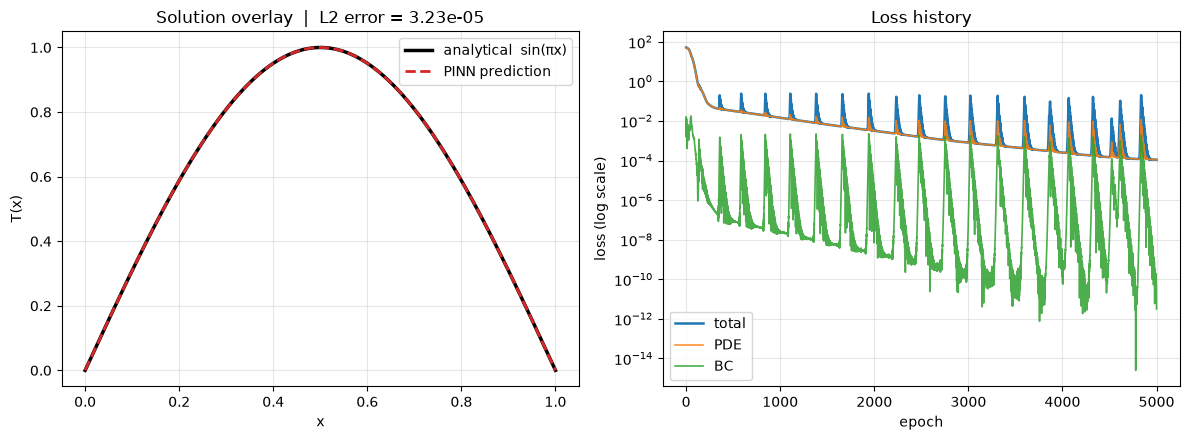

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Solution overlay
ax = axes[0]
ax.plot(x_eval.numpy(), T_true.numpy(), label="analytical  sin(πx)",
        lw=2.5, color="black")
ax.plot(x_eval.numpy(), T_pred.numpy(), "--", label="PINN prediction",
        lw=2.0, color="tab:red")
ax.set_xlabel("x")
ax.set_ylabel("T(x)")
ax.set_title(f"Solution overlay  |  L2 error = {err:.2e}")
ax.legend(); ax.grid(alpha=0.3)

# (b) Loss history
ax = axes[1]
ax.semilogy(hist_total, label="total", lw=1.8)
ax.semilogy(hist_pde,   label="PDE",   lw=1.2, alpha=0.85)
ax.semilogy(hist_bc,    label="BC",    lw=1.2, alpha=0.85)
ax.set_xlabel("epoch")
ax.set_ylabel("loss (log scale)")
ax.set_title("Loss history")
ax.legend(); ax.grid(alpha=0.3, which="both")

fig.tight_layout()
plt.show()

## 8. Bonus diagnostic — residual across the domain

Beyond the scalar L2 error, we can inspect **where** the network is making mistakes.
Plot $r(x) = -T_\theta''(x) - Q(x)$ across the domain. A well-trained PINN has
uniformly tiny residual; if you see spikes near boundaries or at high-curvature
regions, that tells you where to **adaptively refine** collocation points in future
experiments (a technique called Residual-based Adaptive Refinement, or RAR).

This diagnostic is impossible in classical FEM — the residual is only defined at
mesh nodes. In a PINN, the residual is a *continuous function* you can sample anywhere.
That's a genuine capability difference worth appreciating.

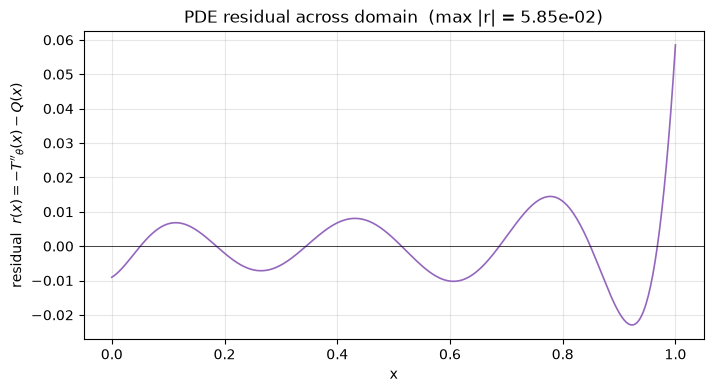

In [8]:
# Evaluate residual on a dense grid — need requires_grad=True this time,
# because we're computing T'' via autograd.
x_dense = torch.linspace(0.0, 1.0, 500).view(-1, 1).requires_grad_(True)
r_dense = pde_residual(model, x_dense).detach().numpy()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_dense.detach().numpy(), r_dense, color="tab:purple", lw=1.2)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("x")
ax.set_ylabel(r"residual  $r(x) = -T''_\theta(x) - Q(x)$")
ax.set_title(f"PDE residual across domain  (max |r| = {np.abs(r_dense).max():.2e})")
ax.grid(alpha=0.3)
plt.show()